# **ENVIROMENT INITIALIZATION**

In [1]:
# IMPORTS
# Math libraries
import numpy as np
from scipy import stats
import pandas as pd
import polars as pl

# Plots
import matplotlib.pyplot as plt

# Technical libraries
from pathlib import Path
from datetime import date, timedelta, datetime
import json

# ML libraries
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import mean_squared_error, roc_auc_score, precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix
import optuna
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# CONFIGURATION
from config import (
    PROJECT_ROOT,
    DATA_PROCESSED_DIR, DATA_FEATURES_DIR,
    CV_FEATURES_PATH, CV_SPLIT_PATH,
    REPORTS_DIR,
    REPORTS_MODELS_DIR, REPORTS_MODELS_GRAPHS_DIR, REPORTS_MODELS_LOGS_DIR,
    MODELS_DIR,
    RANDOM_STATE
)

In [3]:
# DATA PREPARING
# Load features and split labels

# Load features (with cluster)
all_features = pl.read_parquet(CV_FEATURES_PATH)

print(f"Loaded features shape: {all_features.shape}")
print(f"Columns: {all_features.columns}")

# Verify cluster is in the dataset
if "cluster" not in all_features.columns:
    print("\nWARNING: 'cluster' column not found in features!")
else:
    print(f"\n'cluster' column found")
    print(f"Cluster distribution:")
    cluster_dist = all_features.group_by("cluster").agg(pl.len().alias("count"))
    print(cluster_dist)

# Verify is_train is in the dataset
if "is_train" not in all_features.columns:
    print("\nWARNING: 'is_train' column not found in features!")
else:
    print(f"\n'is_train' column found")
    train_count = all_features.filter(pl.col("is_train") == 1).height
    val_count = all_features.filter(pl.col("is_train") == 0).height
    print(f"Train users: {train_count}")
    print(f"Val users: {val_count}")

# Get train/val masks
train_mask = all_features["is_train"].to_numpy() == 1
train_idx = np.where(train_mask)[0]
val_idx = np.where(~train_mask)[0]

print(f"\nLoaded split labels:")
print(f"  Train users: {len(train_idx)}")
print(f"  Val users: {len(val_idx)}")

# Extract features and target (exclude user_id, target, is_train)
# IMPORTANT: cluster is included as a feature
feature_cols = [
    c for c in all_features.columns 
    if c not in ["user_id", "target", "is_train"]
]

print(f"\nNumber of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

X = all_features[feature_cols].to_numpy()
y = all_features["target"].to_numpy()
user_ids = all_features["user_id"].to_numpy()

print(f"\nFeature extraction:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Users with positive target: {(y > 0).sum()}, ({(y > 0).sum() / 250000:.2f}%)")
print(f"  Users with zero target: {(y == 0).sum()}, ({(y == 0).sum() / 250000:.2f}%)")

# Create train/val arrays
X_clf_train = X[train_idx]
X_clf_val = X[val_idx]
y_clf_train = (y[train_idx] > 0).astype(int)
y_clf_val = (y[val_idx] > 0).astype(int)

print(f"\nTrain/Val arrays:")
print(f"  Train X shape: {X_clf_train.shape}")
print(f"  Val X shape: {X_clf_val.shape}")
print(f"  Train positive users: {y_clf_train.sum()}")
print(f"  Val positive users: {y_clf_val.sum()}")

Loaded features shape: (250000, 64)
Columns: ['user_id', 'recency_activity', 'recency_order', 'recency_cart', 'recency_search', 'recency_cat', 'active_days_7d', 'orders_7d', 'cart_adds_7d', 'searches_7d', 'active_days_14d', 'orders_14d', 'cart_adds_14d', 'searches_14d', 'active_days_30d', 'orders_30d', 'cart_adds_30d', 'searches_30d', 'active_days_90d', 'orders_90d', 'cart_adds_90d', 'searches_90d', 'gmv_7d', 'gmv_search_7d', 'gmv_cat_7d', 'gmv_14d', 'gmv_cat_14d', 'gmv_30d', 'gmv_cat_30d', 'gmv_90d', 'gmv_cat_90d', 'weekend_days', 'tuesday_gmv', 'saturday_gmv', 'sunday_gmv', 'weekend_gmv', 'weekend_order_share', 'weekend_gmv_share', 'search_to_cart_rate', 'search_to_ord_rate', 'cart_to_ord_rate', 'cat_to_cart_rate', 'cat_to_ord_rate', 'orders_per_active_day', 'carts_per_active_day', 'salary_day_gmv', 'total_gmv', 'salary_day_order_share', 'salary_day_gmv_share', 'salary_day_aov', 'non_salary_day_aov', 'search_gmv_share_30d', 'search_gmv_share_90d', 'uses_both_channels_30d', 'uses_both

In [4]:
# PREPARE CLASSIFICATION DATA
print(f"Train X shape: {X_clf_train.shape}")
print(f"Val X shape: {X_clf_val.shape}")
print(f"Train positive users: {y_clf_train.sum()}, ratio: {y_clf_train.mean():.4f}")
print(f"Val positive users: {y_clf_val.sum()}, ratio: {y_clf_val.mean():.4f}")

# PREPARE REGRESSION DATA
# Positive mask within train split
positive_mask_train = y[train_idx] > 0

X_reg_train = X[train_idx][positive_mask_train]
y_reg_train_raw = y[train_idx][positive_mask_train]
y_reg_train = np.log1p(y_reg_train_raw)

# For regression validation, we use positive users from VAL split
positive_mask_val = y[val_idx] > 0

X_reg_val = X[val_idx][positive_mask_val]
y_reg_val_raw = y[val_idx][positive_mask_val]
y_reg_val = np.log1p(y_reg_val_raw)

print(f"\nTrain data:")
print(f"  Shape: {X_reg_train.shape}")
print(f"  Positive users: {positive_mask_train.sum()}")
print(f"  y (log1p) mean: {y_reg_train.mean():.4f}")

print(f"\nVal data (positive only):")
print(f"  Shape: {X_reg_val.shape}")
print(f"  Positive users: {positive_mask_val.sum()}")
print(f"  y (log1p) mean: {y_reg_val.mean():.4f}")

Train X shape: (200000, 61)
Val X shape: (50000, 61)
Train positive users: 108132, ratio: 0.5407
Val positive users: 27033, ratio: 0.5407

Train data:
  Shape: (108132, 61)
  Positive users: 108132
  y (log1p) mean: 4.1468

Val data (positive only):
  Shape: (27033, 61)
  Positive users: 27033
  y (log1p) mean: 4.1478


In [5]:
# DEFINE RMSLE FUNCTION (should be defined once at the top)
def rmsle(y_true, y_pred):
    """Root Mean Squared Logarithmic Error"""
    y_true = np.asarray(y_true, dtype = np.float64)
    y_pred = np.asarray(y_pred, dtype = np.float64)
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))

In [6]:
# Custom RMSLE evaluation function for LightGBM
def rmsle_eval(y_pred, dataset):
    y_true = dataset.get_label()
    y_pred = np.clip(y_pred, 0, None)
    score = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    return "rmsle", score, False  # False = lower is better

# **MODELS LEARNING**

## **DESIGN 2: BINARY CLASSIFIER + POSITIVE SHARES REGRESSOR blends with TWEEDIE REGRESSION**

In [7]:
# BINARY CLASSIFIER (using unified split with cluster feature)
train_data_clf = lgb.Dataset(X_clf_train, label = y_clf_train)
val_data_clf = lgb.Dataset(X_clf_val, label = y_clf_val, reference = train_data_clf)

params_clf = {
    "objective": "binary",
    "metric": "binary_logloss",
    "learning_rate": 0.04,
    "num_leaves": 63,
    "max_depth": 6,
    "min_child_samples": 60,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
    "random_state": RANDOM_STATE
}

clf = lgb.train(
    params_clf,
    train_data_clf,
    num_boost_round = 1000,
    valid_sets = [train_data_clf, val_data_clf],
    valid_names = ["train", "val"],
    callbacks = [
        lgb.early_stopping(stopping_rounds = 200),
        lgb.log_evaluation(period = 100),
    ],
)

print(f"\nBest iteration: {clf.best_iteration}")

# Evaluate classifier on val only
y_clf_val_pred = clf.predict(X_clf_val)
val_auc = roc_auc_score(y_clf_val, y_clf_val_pred)
print(f"Val AUC: {val_auc:.4f}")

y_clf_val_pred_binary = (y_clf_val_pred > 0.5).astype(int)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_clf_val, y_clf_val_pred_binary, average = "binary"
)
print(f"Val Precision: {precision:.4f}")
print(f"Val Recall: {recall:.4f}")
print(f"Val F1: {f1:.4f}")

Training until validation scores don't improve for 200 rounds
[100]	train's binary_logloss: 0.464572	val's binary_logloss: 0.469412
[200]	train's binary_logloss: 0.456741	val's binary_logloss: 0.468133
[300]	train's binary_logloss: 0.451387	val's binary_logloss: 0.468086
[400]	train's binary_logloss: 0.446399	val's binary_logloss: 0.468267
Early stopping, best iteration is:
[250]	train's binary_logloss: 0.453952	val's binary_logloss: 0.46802

Best iteration: 250
Val AUC: 0.8566
Val Precision: 0.7913
Val Recall: 0.7925
Val F1: 0.7919


In [8]:
# REGRESSOR (using unified split with cluster feature)
train_data_reg = lgb.Dataset(X_reg_train, label = y_reg_train)
val_data_reg = lgb.Dataset(X_reg_val, label = y_reg_val, reference = train_data_reg)

params_reg = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.06,
    "num_leaves": 63,
    "max_depth": 6,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.15,
    "reg_lambda": 0.15,
    "verbose": -1,
    "n_jobs": -1,
    "random_state": RANDOM_STATE
}

reg = lgb.train(
    params_reg,
    train_data_reg,
    num_boost_round = 1000,
    valid_sets = [train_data_reg, val_data_reg],
    valid_names = ["train", "val"],
    callbacks = [
        lgb.early_stopping(stopping_rounds = 200),
        lgb.log_evaluation(period = 100),
    ],
)

print(f"\nBest iteration: {reg.best_iteration}")

# Evaluate regressor on val positive users only
y_reg_val_pred = reg.predict(X_reg_val)
val_rmse_log = np.sqrt(mean_squared_error(y_reg_val, y_reg_val_pred))
print(f"Val RMSE (log space): {val_rmse_log:.4f}")

y_reg_val_pred_raw = np.expm1(y_reg_val_pred)
val_rmse_raw = np.sqrt(mean_squared_error(y_reg_val_raw, y_reg_val_pred_raw))
print(f"Val RMSE (raw): {val_rmse_raw:.4f}")

Training until validation scores don't improve for 200 rounds
[100]	train's rmse: 1.07608	val's rmse: 1.1072
[200]	train's rmse: 1.06007	val's rmse: 1.10674
[300]	train's rmse: 1.04517	val's rmse: 1.10703
[400]	train's rmse: 1.03115	val's rmse: 1.10778
Early stopping, best iteration is:
[218]	train's rmse: 1.05729	val's rmse: 1.1066

Best iteration: 218
Val RMSE (log space): 1.1066
Val RMSE (raw): 411.7869


### **TRYING TO OPTIMIZE THRESHOLD**

In [9]:
# THRESHOLD OPTIMIZATION
# Find the optimal threshold / alpha that minimizes overall RMSLE on val set
print("THRESHOLD OPTIMIZATION")

# Re-compute predictions on validation set (they should already exist)
P_buy_val = clf.predict(X_clf_val)
predicted_gmv_log_val = reg.predict(X_clf_val)
predicted_gmv_val = np.expm1(predicted_gmv_log_val)
predicted_gmv_val = np.clip(predicted_gmv_val, 0, None)

y_val = y[val_idx]

print(f"Val size: {len(y_val)}")
print(f"Val positive: {y_val.sum() > 0}")
print(f"P_buy_val range: [{P_buy_val.min():.4f}, {P_buy_val.max():.4f}]")
print(f"predicted_gmv_val range: [{predicted_gmv_val.min():.2f}, {predicted_gmv_val.max():.2f}]")

THRESHOLD OPTIMIZATION
Val size: 50000
Val positive: True
P_buy_val range: [0.0213, 0.9995]
predicted_gmv_val range: [5.62, 3482.28]


In [10]:
# VARIANT 1: HARD GATE (0 if P_buy < threshold, else predicted_gmv)
# Most aggressive: completely zero out low-probability users

thresholds = np.arange(0.05, 0.95, 0.01)
hard_gate_results = []

for t in thresholds:
    pred = np.where(P_buy_val < t, 0.0, predicted_gmv_val)
    score = rmsle(y_val, pred)
    hard_gate_results.append({
        "threshold": t,
        "rmsle": score,
        "zero_share": (pred == 0).mean(),
    })

hard_gate_df = pd.DataFrame(hard_gate_results)
best_hard = hard_gate_df.loc[hard_gate_df["rmsle"].idxmin()]

print(f"Best threshold: {best_hard['threshold']:.3f}")
print(f"Best RMSLE: {best_hard['rmsle']:.4f}")
print(f"Zero share at best threshold: {best_hard['zero_share']:.3f}")

# VARIANT 2: HYBRID GATE (0 if P_buy < threshold, else P_buy * predicted_gmv)
# Soft cutoff: preserve probability information above threshold

hybrid_results = []

for t in thresholds:
    pred = np.where(P_buy_val < t, 0.0, P_buy_val * predicted_gmv_val)
    score = rmsle(y_val, pred)
    hybrid_results.append({
        "threshold": t,
        "rmsle": score,
        "zero_share": (pred == 0).mean(),
    })

hybrid_df = pd.DataFrame(hybrid_results)
best_hybrid = hybrid_df.loc[hybrid_df["rmsle"].idxmin()]

print(f"Best threshold: {best_hybrid['threshold']:.3f}")
print(f"Best RMSLE: {best_hybrid['rmsle']:.4f}")
print(f"Zero share at best threshold: {best_hybrid['zero_share']:.3f}")

# VARIANT 3: POWER GATE ((P_buy ^ alpha) * predicted_gmv)
# Continuous control: alpha > 1 compresses low probabilities more

alphas = np.arange(0.5, 5.0, 0.01)
power_results = []

for alpha in alphas:
    pred = (P_buy_val ** alpha) * predicted_gmv_val
    pred = np.clip(pred, 0, None)
    score = rmsle(y_val, pred)
    power_results.append({
        "alpha": alpha,
        "rmsle": score,
        "mean_pred": pred.mean(),
    })

power_df = pd.DataFrame(power_results)
best_power = power_df.loc[power_df["rmsle"].idxmin()]

print(f"Best alpha: {best_power['alpha']:.2f}")
print(f"Best RMSLE: {best_power['rmsle']:.4f}")
print(f"Mean prediction at best alpha: {best_power['mean_pred']:.4f}")

# COMPARISON OF ALL VARIANTS
print("\nCOMPARISON")

# Baseline: soft (alpha = 1)
soft_pred = P_buy_val * predicted_gmv_val
soft_rmsle = rmsle(y_val, soft_pred)

results_summary = pd.DataFrame({
    "variant": ["Soft (baseline)", "Hard gate", "Hybrid gate", "Power gate"],
    "param": [
        "alpha = 1",
        f"t = {best_hard['threshold']:.3f}",
        f"t = {best_hybrid['threshold']:.3f}",
        f"alpha = {best_power['alpha']:.2f}",
    ],
    "rmsle": [
        soft_rmsle,
        best_hard["rmsle"],
        best_hybrid["rmsle"],
        best_power["rmsle"],
    ],
})

results_summary["improvement_vs_soft (%)"] = (
    (soft_rmsle - results_summary["rmsle"]) / soft_rmsle * 100
)

print(results_summary.to_string(index = False))

Best threshold: 0.500
Best RMSLE: 1.9292
Zero share at best threshold: 0.459
Best threshold: 0.360
Best RMSLE: 1.8345
Zero share at best threshold: 0.340
Best alpha: 2.64
Best RMSLE: 1.6818
Mean prediction at best alpha: 39.3524

COMPARISON
        variant        param    rmsle  improvement_vs_soft (%)
Soft (baseline)    alpha = 1 1.912407                 0.000000
      Hard gate    t = 0.500 1.929153                -0.875658
    Hybrid gate    t = 0.360 1.834496                 4.074003
     Power gate alpha = 2.64 1.681768                12.060172


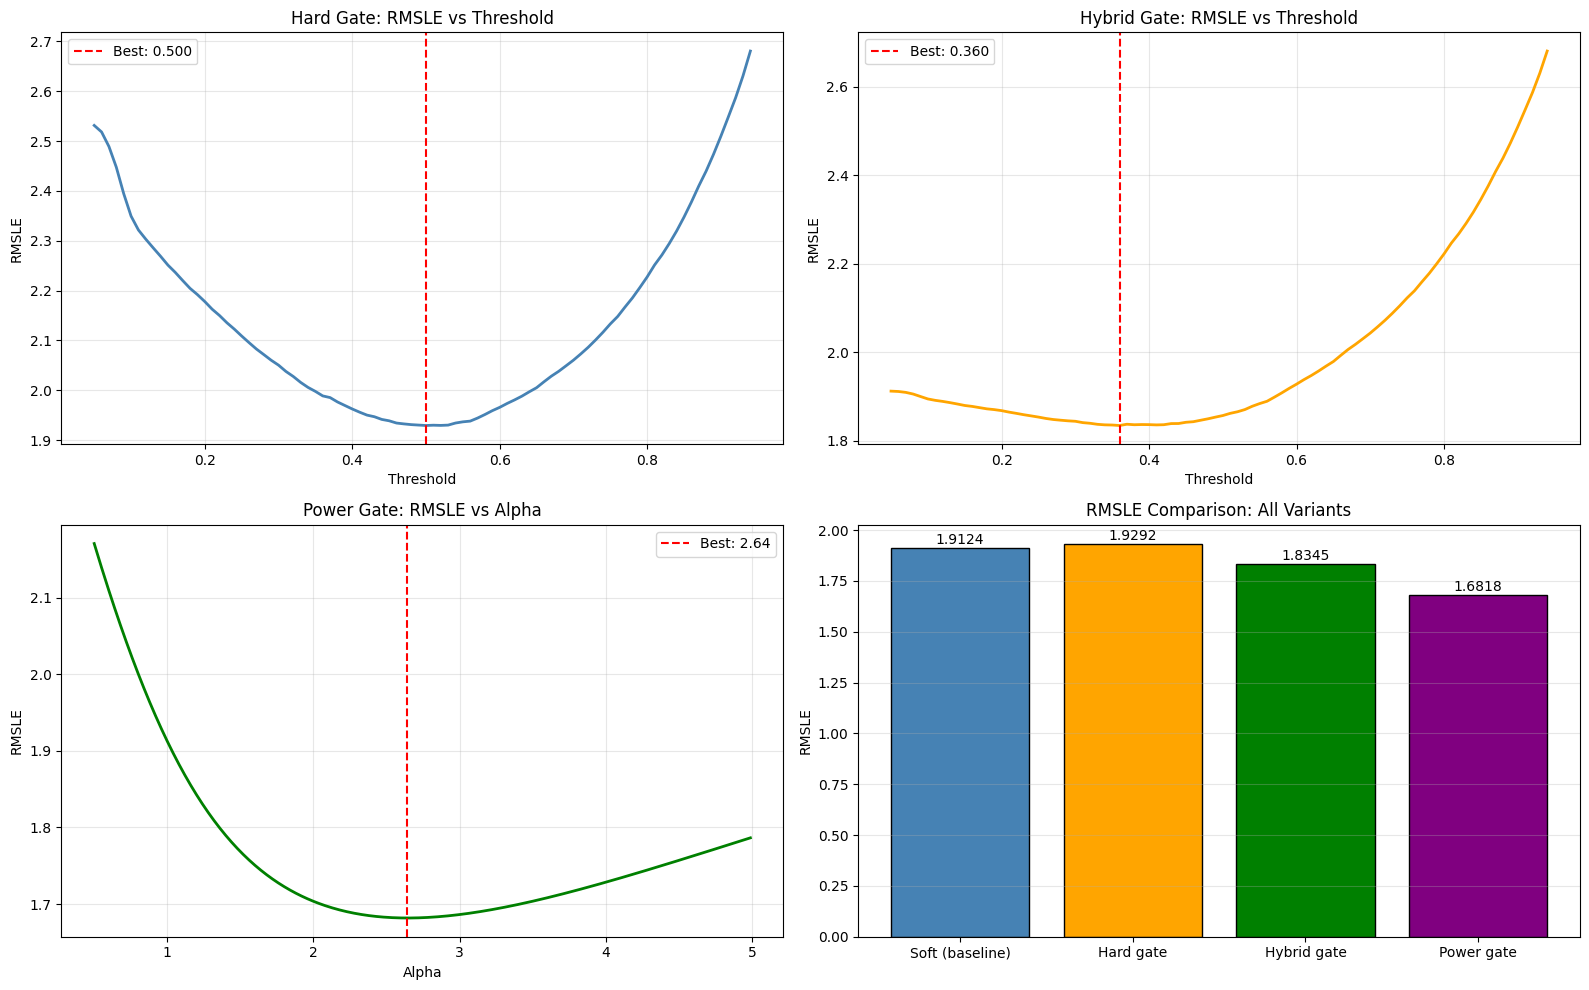

Plot saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\graphs\25_baseline_threshold_opt.png


In [11]:
# VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Plot 1: Hard gate RMSLE vs threshold
axes[0, 0].plot(hard_gate_df["threshold"], hard_gate_df["rmsle"], color = "steelblue", linewidth = 2)
axes[0, 0].axvline(best_hard["threshold"], color = "red", linestyle = "--", 
                   label = f"Best: {best_hard['threshold']:.3f}")
axes[0, 0].set_title("Hard Gate: RMSLE vs Threshold")
axes[0, 0].set_xlabel("Threshold")
axes[0, 0].set_ylabel("RMSLE")
axes[0, 0].legend()
axes[0, 0].grid(alpha = 0.3)

# Plot 2: Hybrid gate RMSLE vs threshold
axes[0, 1].plot(hybrid_df["threshold"], hybrid_df["rmsle"], color = "orange", linewidth = 2)
axes[0, 1].axvline(best_hybrid["threshold"], color = "red", linestyle = "--", 
                   label = f"Best: {best_hybrid['threshold']:.3f}")
axes[0, 1].set_title("Hybrid Gate: RMSLE vs Threshold")
axes[0, 1].set_xlabel("Threshold")
axes[0, 1].set_ylabel("RMSLE")
axes[0, 1].legend()
axes[0, 1].grid(alpha = 0.3)

# Plot 3: Power gate RMSLE vs alpha
axes[1, 0].plot(power_df["alpha"], power_df["rmsle"], color = "green", linewidth = 2)
axes[1, 0].axvline(best_power["alpha"], color = "red", linestyle = "--", 
                   label = f"Best: {best_power['alpha']:.2f}")
axes[1, 0].set_title("Power Gate: RMSLE vs Alpha")
axes[1, 0].set_xlabel("Alpha")
axes[1, 0].set_ylabel("RMSLE")
axes[1, 0].legend()
axes[1, 0].grid(alpha = 0.3)

# Plot 4: All variants together
axes[1, 1].bar(
    results_summary["variant"],
    results_summary["rmsle"],
    color = ["steelblue", "orange", "green", "purple"],
    edgecolor = "black",
)
axes[1, 1].set_title("RMSLE Comparison: All Variants")
axes[1, 1].set_ylabel("RMSLE")
axes[1, 1].grid(alpha = 0.3, axis = "y")

for i, row in results_summary.iterrows():
    axes[1, 1].text(
        i, row["rmsle"] + 0.005,
        f"{row['rmsle']:.4f}",
        ha = "center", va = "bottom",
    )

plt.tight_layout()
fig.savefig(REPORTS_MODELS_GRAPHS_DIR / "25_baseline_threshold_opt.png", dpi = 150)
plt.show()

print(f"Plot saved to: {REPORTS_MODELS_GRAPHS_DIR / '25_baseline_threshold_opt.png'}")

### **GENERALIZING PREDICTION ON VALIDATION**

In [12]:
# ARCHITECTURE 1: CLASSIFIER + REGULAR REGRESSOR (with power gate)
OPTIMAL_ALPHA = 2.65  # From previous threshold optimization

# Predict on val users
P_buy_val = clf.predict(X_clf_val)
predicted_gmv_log_val = reg.predict(X_clf_val)
predicted_gmv_val_regular = np.expm1(predicted_gmv_log_val)
predicted_gmv_val_regular = np.clip(predicted_gmv_val_regular, 0, None)

# Final prediction with power gate
final_pred_arch1 = (P_buy_val ** OPTIMAL_ALPHA) * predicted_gmv_val_regular
final_pred_arch1 = np.clip(final_pred_arch1, 0, None)

# True target for val users
y_val = y[val_idx]

print(f"Optimal alpha: {OPTIMAL_ALPHA}")
print(f"Val prediction mean: {final_pred_arch1.mean():.4f}")
print(f"Val prediction median: {np.median(final_pred_arch1):.4f}")
print(f"Val prediction max: {final_pred_arch1.max():.4f}")

# Evaluate architecture 1
rmsle_arch1 = rmsle(y_val, final_pred_arch1)
print(f"\nArchitecture 1 RMSLE: {rmsle_arch1:.4f}")

# Compare with soft baseline
soft_pred_val = P_buy_val * predicted_gmv_val_regular
soft_rmsle_val = rmsle(y_val, soft_pred_val)
print(f"Soft baseline RMSLE (alpha=1): {soft_rmsle_val:.4f}")
print(f"Improvement from power gate: {(soft_rmsle_val - rmsle_arch1) / soft_rmsle_val * 100:.2f}%")

Optimal alpha: 2.65
Val prediction mean: 39.3140
Val prediction median: 7.4510
Val prediction max: 3426.4099

Architecture 1 RMSLE: 1.6818
Soft baseline RMSLE (alpha=1): 1.9124
Improvement from power gate: 12.06%


### **CHECKING RESULTS BY CLASTERS**

Unique clusters in val: [0 1 2 3]

Cluster 0:
  Users: 27617 (positive: 12873, negative: 14744)
  Confusion matrix: TN = 10838, FP = 3906, FN = 4805, TP = 8068
  Accuracy: 0.6846
  Precision: 0.6738
  Recall: 0.6267
  F1: 0.6494

Cluster 1:
  Users: 6862 (positive: 637, negative: 6225)
  Confusion matrix: TN = 6225, FP = 0, FN = 637, TP = 0
  Accuracy: 0.9072
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000

Cluster 2:
  Users: 14431 (positive: 12459, negative: 1972)
  Confusion matrix: TN = 250, FP = 1722, FN = 167, TP = 12292
  Accuracy: 0.8691
  Precision: 0.8771
  Recall: 0.9866
  F1: 0.9286

Cluster 3:
  Users: 1090 (positive: 1064, negative: 26)
  Confusion matrix: TN = 5, FP = 21, FN = 1, TP = 1063
  Accuracy: 0.9798
  Precision: 0.9806
  Recall: 0.9991
  F1: 0.9898


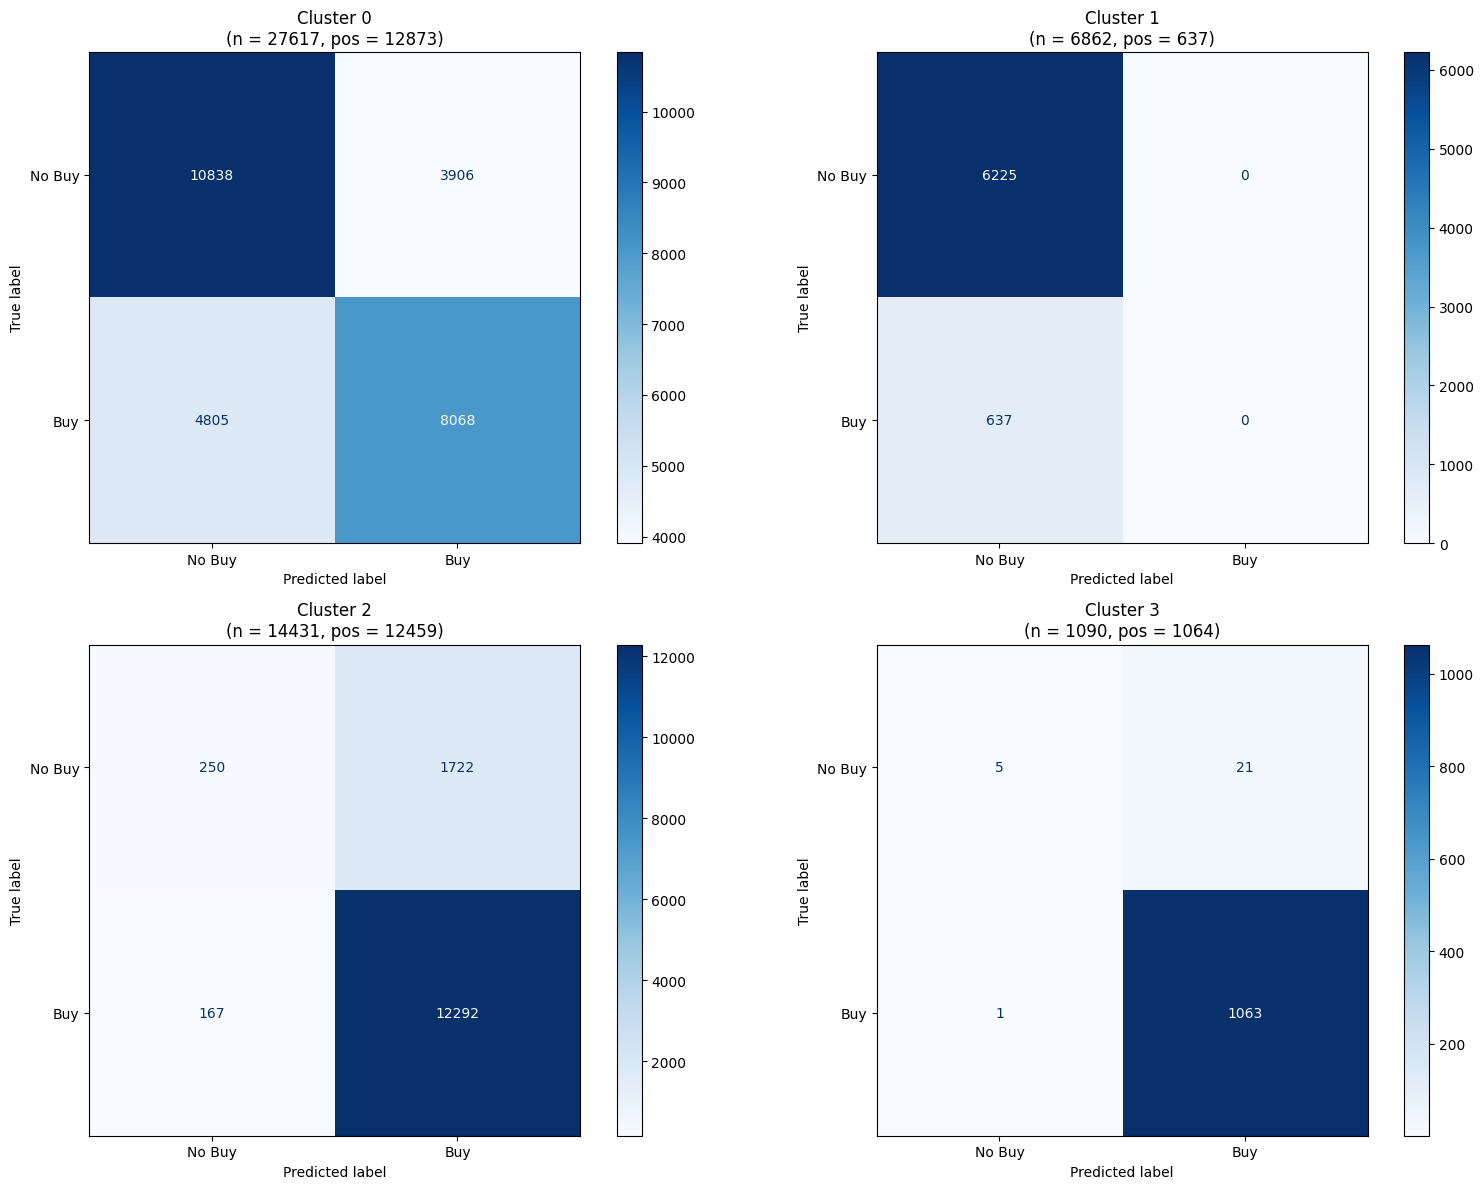

Classifier error analysis saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\graphs\03_lgbm_clf_reg_v2\classifier_errors_by_cluster.png


In [13]:
# ERROR ANALYSIS: CLASSIFIER BY CLUSTERS
# Get cluster labels for val users
val_clusters = all_features["cluster"].to_numpy()[val_idx]

# Classifier predictions on val users
y_clf_val_pred = clf.predict(X_clf_val)
y_clf_val_pred_binary = (y_clf_val_pred > 0.5).astype(int)

# True labels for val users
y_clf_val_true = y_clf_val

# Get unique clusters
unique_clusters = np.unique(val_clusters)
print(f"Unique clusters in val: {unique_clusters}")

# Analyze each cluster
fig, axes = plt.subplots(2, 2, figsize = (16, 12))
axes = axes.flatten()

for i, cluster_id in enumerate(sorted(unique_clusters)):
    # Filter to this cluster
    cluster_mask = val_clusters == cluster_id
    y_true_cluster = y_clf_val_true[cluster_mask]
    y_pred_cluster = y_clf_val_pred_binary[cluster_mask]
    y_prob_cluster = y_clf_val_pred[cluster_mask]
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true_cluster, y_pred_cluster)
    
    # Calculate metrics
    n_users = len(y_true_cluster)
    n_positive = y_true_cluster.sum()
    n_negative = n_users - n_positive
    
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    accuracy = (tn + tp) / n_users if n_users > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\nCluster {cluster_id}:")
    print(f"  Users: {n_users} (positive: {n_positive}, negative: {n_negative})")
    print(f"  Confusion matrix: TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1: {f1:.4f}")
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Buy", "Buy"])
    disp.plot(cmap = "Blues", ax = axes[i])
    axes[i].set_title(f"Cluster {cluster_id}\n(n = {n_users}, pos = {n_positive})")

plt.tight_layout()
fig.savefig(REPORTS_MODELS_GRAPHS_DIR / "03_lgbm_clf_reg_v2" / "classifier_errors_by_cluster.png", dpi = 150)
plt.show()

print(f"Classifier error analysis saved to: {REPORTS_MODELS_GRAPHS_DIR / "03_lgbm_clf_reg_v2" / 'classifier_errors_by_cluster.png'}")

In [14]:
# ERROR ANALYSIS: REGRESSORS BY CLUSTERS
# Predictions on ALL val users (not just positive)
predicted_gmv_val_regular_all = np.expm1(reg.predict(X_clf_val))
predicted_gmv_val_regular_all = np.clip(predicted_gmv_val_regular_all, 0, None)

# True target for val users
y_val_all = y[val_idx]

# Analyze each cluster
results_by_cluster = []

for cluster_id in sorted(unique_clusters):
    cluster_mask = val_clusters == cluster_id
    
    y_true_cluster = y_val_all[cluster_mask]
    pred_regular_cluster = predicted_gmv_val_regular_all[cluster_mask]
    
    n_users = len(y_true_cluster)
    n_positive = (y_true_cluster > 0).sum()
    
    # Calculate metrics for regular regressor
    rmsle_regular_cluster = rmsle(y_true_cluster, pred_regular_cluster)
    mae_regular_cluster = np.mean(np.abs(y_true_cluster - pred_regular_cluster))
    
    rmsle_blend_cluster = rmsle(y_true_cluster, pred_regular_cluster)
    
    results_by_cluster.append({
        "cluster": cluster_id,
        "n_users": n_users,
        "n_positive": n_positive,
        "pct_positive": n_positive / n_users * 100 if n_users > 0 else 0,
        "mean_target": y_true_cluster.mean(),
        "rmsle_regular": rmsle_regular_cluster,
        "mae_regular": mae_regular_cluster
    })

results_df = pd.DataFrame(results_by_cluster)

print("Error analysis by cluster:")
print(results_df.to_string(index = False))

Error analysis by cluster:
 cluster  n_users  n_positive  pct_positive  mean_target  rmsle_regular  mae_regular
       0    27617       12873     46.612594    40.868546       2.711019    50.617023
       1     6862         637      9.283008     6.354493       3.211144    30.388966
       2    14431       12459     86.334973   154.705146       1.796953   115.345217
       3     1090        1064     97.614679   761.736390       1.277211   471.679918


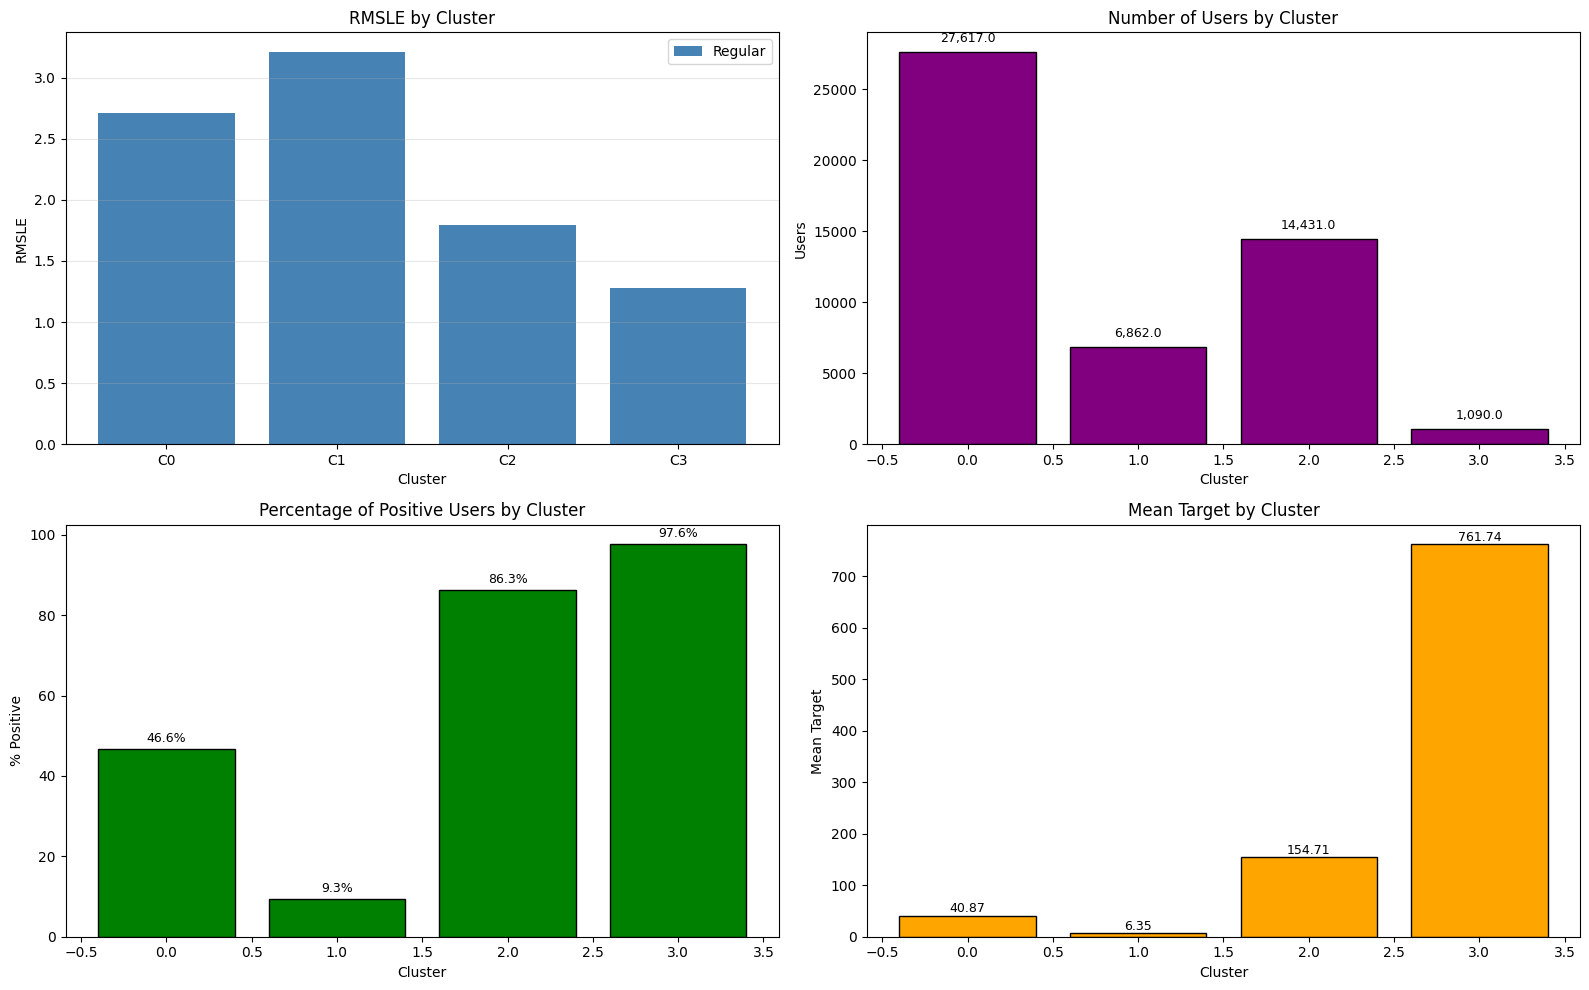

Regressor error analysis saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\graphs\03_lgbm_clf_reg_v2\regressor_errors_by_cluster.png


In [15]:
# VISUALIZE REGRESSOR ERRORS BY CLUSTER
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Plot 1: RMSLE by cluster
x = np.arange(len(results_df))

axes[0, 0].bar(x, results_df["rmsle_regular"], label = "Regular", color = "steelblue")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels([f"C{c}" for c in results_df["cluster"]])
axes[0, 0].set_title("RMSLE by Cluster")
axes[0, 0].set_xlabel("Cluster")
axes[0, 0].set_ylabel("RMSLE")
axes[0, 0].legend()
axes[0, 0].grid(alpha = 0.3, axis = "y")

# Plot 2: Number of users by cluster
axes[0, 1].bar(results_df["cluster"], results_df["n_users"], color = "purple", edgecolor = "black")
axes[0, 1].set_title("Number of Users by Cluster")
axes[0, 1].set_xlabel("Cluster")
axes[0, 1].set_ylabel("Users")
for i, row in results_df.iterrows():
    axes[0, 1].text(i, row["n_users"] + 500, f"{row['n_users']:,}", 
                    ha = "center", va = "bottom", fontsize = 9)

# Plot 3: Percentage of positive users by cluster
axes[1, 0].bar(results_df["cluster"], results_df["pct_positive"], color = "green", edgecolor = "black")
axes[1, 0].set_title("Percentage of Positive Users by Cluster")
axes[1, 0].set_xlabel("Cluster")
axes[1, 0].set_ylabel("% Positive")
for i, row in results_df.iterrows():
    axes[1, 0].text(i, row["pct_positive"] + 1, f"{row['pct_positive']:.1f}%", 
                    ha = "center", va = "bottom", fontsize = 9)

# Plot 4: Mean target by cluster
axes[1, 1].bar(results_df["cluster"], results_df["mean_target"], color = "orange", edgecolor = "black")
axes[1, 1].set_title("Mean Target by Cluster")
axes[1, 1].set_xlabel("Cluster")
axes[1, 1].set_ylabel("Mean Target")
for i, row in results_df.iterrows():
    axes[1, 1].text(i, row["mean_target"] + 1, f"{row['mean_target']:.2f}", 
                    ha = "center", va = "bottom", fontsize = 9)

plt.tight_layout()
fig.savefig(REPORTS_MODELS_GRAPHS_DIR / "03_lgbm_clf_reg_v2" / "regressor_errors_by_cluster.png", dpi = 150)
plt.show()

print(f"Regressor error analysis saved to: {REPORTS_MODELS_GRAPHS_DIR / "03_lgbm_clf_reg_v2" / 'regressor_errors_by_cluster.png'}")

In [16]:
# FEATURE IMPORTANCE
feature_importance_clf = pd.DataFrame({
    "feature": feature_cols,
    "importance": clf.feature_importance(importance_type = "gain"),
}).sort_values("importance", ascending = False)

print("Top 20 features (classifier):")
print(feature_importance_clf.head(20))

# Check cluster importance
cluster_importance_clf = feature_importance_clf[feature_importance_clf["feature"] == "cluster"]
if not cluster_importance_clf.empty:
    print(f"\nCluster importance (classifier): {cluster_importance_clf['importance'].values[0]:.2f}")

feature_importance_reg = pd.DataFrame({
    "feature": feature_cols,
    "importance": reg.feature_importance(importance_type = "gain"),
}).sort_values("importance", ascending = False)

print("\nTop 20 features (regressor):")
print(feature_importance_reg.head(20))

# Check cluster importance
cluster_importance_reg = feature_importance_reg[feature_importance_reg["feature"] == "cluster"]
if not cluster_importance_reg.empty:
    print(f"\nCluster importance (regressor): {cluster_importance_reg['importance'].values[0]:.2f}")

Top 20 features (classifier):
                  feature     importance
18             orders_90d  581111.736783
28                gmv_90d  172593.691164
1           recency_order  138076.403557
45              total_gmv   38403.850844
60                cluster   36449.346729
14             orders_30d   31101.137325
42  orders_per_active_day   23603.398825
13        active_days_30d   13271.279863
30           weekend_days   10565.520394
49     non_salary_day_aov   10563.423589
5          active_days_7d    9523.132698
17        active_days_90d    9466.423729
38     search_to_ord_rate    8295.891405
31            tuesday_gmv    7254.066632
48         salary_day_aov    6654.197556
9         active_days_14d    6638.902018
2            recency_cart    6580.429748
39       cart_to_ord_rate    6293.925214
0        recency_activity    5334.511504
3          recency_search    5211.972895

Cluster importance (classifier): 36449.35

Top 20 features (regressor):
                  feature     import

### **OPTIMIZATION**

In [17]:
# OPTIMIZATION: CLASSIFIER WITH CROSS-VALIDATION
from sklearn.model_selection import StratifiedKFold

# Creating files for logs
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
clf_log_file = REPORTS_MODELS_LOGS_DIR / "03_lgbm_clf_reg_v2" / f"clf_optimization_cv_{timestamp}.log"
clf_params_file = REPORTS_MODELS_LOGS_DIR / "03_lgbm_clf_reg_v2" / f"clf_best_params_cv_{timestamp}.json"

# Ensure directory exists
clf_log_file.parent.mkdir(parents = True, exist_ok = True)

print(f"Log file: {clf_log_file}")
print(f"Params file: {clf_params_file}")

# DEFINE OBJECTIVE FUNCTION WITH CROSS-VALIDATION
N_FOLDS = 3
skf = StratifiedKFold(n_splits = N_FOLDS, shuffle = True, random_state = RANDOM_STATE)

def objective_clf(trial):
    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log = True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log = True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log = True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "scale_pos_weight": 1,
        "verbose": -1,
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
    }
    
    # Cross-validation on train data
    cv_aucs = []
    
    for fold_idx, (train_fold_idx, val_fold_idx) in enumerate(skf.split(X_clf_train, y_clf_train)):
        X_train_fold = X_clf_train[train_fold_idx]
        y_train_fold = y_clf_train[train_fold_idx]
        X_val_fold = X_clf_train[val_fold_idx]
        y_val_fold = y_clf_train[val_fold_idx]
        
        train_data = lgb.Dataset(X_train_fold, label = y_train_fold)
        val_data = lgb.Dataset(X_val_fold, label = y_val_fold, reference = train_data)
        
        model = lgb.train(
            params,
            train_data,
            num_boost_round = 1000,
            valid_sets = [val_data],
            valid_names = ["val"],
            callbacks = [
                lgb.early_stopping(stopping_rounds = 100),
                lgb.log_evaluation(period = 0),
            ],
        )
        
        y_val_fold_pred = model.predict(X_val_fold)
        fold_auc = roc_auc_score(y_val_fold, y_val_fold_pred)
        cv_aucs.append(fold_auc)
    
    # Return mean AUC across folds
    return np.mean(cv_aucs)

# RUN OPTIMIZATION
study_clf = optuna.create_study(
    direction = "maximize",
    study_name = "classifier_optimization_cv",
    sampler = optuna.samplers.TPESampler(seed = RANDOM_STATE),
)

# Run optimization (30 trials with CV to save time)
N_TRIALS_CLF = 30
study_clf.optimize(objective_clf, n_trials = N_TRIALS_CLF, show_progress_bar = True)

print(f"\nBest trial:")
print(f"  Mean CV AUC: {study_clf.best_value:.4f}")
print(f"  Params: {study_clf.best_params}")

# SAVE LOGS
log_data = {
    "timestamp": timestamp,
    "best_cv_auc": study_clf.best_value,
    "best_params": study_clf.best_params,
    "n_trials": len(study_clf.trials),
    "n_folds": N_FOLDS,
    "all_trials": [
        {
            "trial_number": t.number,
            "value": t.value,
            "params": t.params,
        }
        for t in study_clf.trials
    ],
}

with open(clf_log_file, "w") as f:
    json.dump(log_data, f, indent = 2)

with open(clf_params_file, "w") as f:
    json.dump(study_clf.best_params, f, indent = 2)

print(f"\nLogs saved to: {clf_log_file}")
print(f"Best params saved to: {clf_params_file}")

[I 2026-08-30 23:34:35,851] A new study created in memory with name: classifier_optimization_cv


Log file: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\03_lgbm_clf_reg_v2\clf_optimization_cv_20260830_233435.log
Params file: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\03_lgbm_clf_reg_v2\clf_best_params_cv_20260830_233435.json


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[393]	val's binary_logloss: 0.469275
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[436]	val's binary_logloss: 0.476906
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[342]	val's binary_logloss: 0.472955


Best trial: 0. Best value: 0.853048:   3%|▎         | 1/30 [00:21<10:18, 21.33s/it]

...

[I 2026-08-30 23:48:19,606] Trial 27 finished with value: 0.8531042273940996 and parameters: {'learning_rate': 0.02614235149718744, 'num_leaves': 170, 'max_depth': 14, 'min_child_samples': 87, 'subsample': 0.824635866281698, 'colsample_bytree': 0.6002339433586326, 'reg_alpha': 3.101924756570301e-07, 'reg_lambda': 0.011408204799610747, 'min_split_gain': 0.6122047736937293}. Best is trial 16 with value: 0.8533113256556438.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[658]	val's binary_logloss: 0.469017
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[530]	val's binary_logloss: 0.476627
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[629]	val's binary_logloss: 0.472699


Best trial: 16. Best value: 0.853311:  97%|█████████▋| 29/30 [14:48<00:45, 45.32s/it]

[I 2026-08-30 23:49:24,242] Trial 28 finished with value: 0.8532647451389989 and parameters: {'learning_rate': 0.010036345751806557, 'num_leaves': 126, 'max_depth': 14, 'min_child_samples': 101, 'subsample': 0.7697565158081181, 'colsample_bytree': 0.6441199847583737, 'reg_alpha': 2.072487209113442e-06, 'reg_lambda': 9.329020620271965, 'min_split_gain': 0.3765758659102363}. Best is trial 16 with value: 0.8533113256556438.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[15]	val's binary_logloss: 0.472849
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[15]	val's binary_logloss: 0.480116
Training until validation scores don't improve for 100 rounds


Best trial: 16. Best value: 0.853311: 100%|██████████| 30/30 [14:58<00:00, 29.94s/it]

Early stopping, best iteration is:
[14]	val's binary_logloss: 0.477182
[I 2026-08-30 23:49:34,135] Trial 29 finished with value: 0.8507865213799791 and parameters: {'learning_rate': 0.25834081623308264, 'num_leaves': 145, 'max_depth': 14, 'min_child_samples': 105, 'subsample': 0.7699473387719366, 'colsample_bytree': 0.6453239874554741, 'reg_alpha': 1.2994150122392137e-08, 'reg_lambda': 8.179901040953883, 'min_split_gain': 0.09713382171688867}. Best is trial 16 with value: 0.8533113256556438.

Best trial:
  Mean CV AUC: 0.8533
  Params: {'learning_rate': 0.017919999552065777, 'num_leaves': 79, 'max_depth': 12, 'min_child_samples': 54, 'subsample': 0.9998404595329797, 'colsample_bytree': 0.6766724057496009, 'reg_alpha': 9.993648710292874e-05, 'reg_lambda': 9.484849867609482, 'min_split_gain': 0.31816056865668085}

Logs saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\03_lgbm_clf_reg_v2\clf_optimization_cv_20260830_233435.log
Best params saved to: D

In [18]:
# TRAIN FINAL CLASSIFIER WITH BEST PARAMS (on full train data)
best_params_clf = study_clf.best_params.copy()
best_params_clf.update({
    "objective": "binary",
    "metric": "binary_logloss",
    "scale_pos_weight": 1,
    "verbose": -1,
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
})

train_data_clf = lgb.Dataset(X_clf_train, label = y_clf_train)
val_data_clf = lgb.Dataset(X_clf_val, label = y_clf_val, reference = train_data_clf)

clf_optimized = lgb.train(
    best_params_clf,
    train_data_clf,
    num_boost_round = 1000,
    valid_sets = [train_data_clf, val_data_clf],
    valid_names = ["train", "val"],
    callbacks = [
        lgb.early_stopping(stopping_rounds = 100),
        lgb.log_evaluation(period = 100),
    ],
)

print(f"\nBest iteration: {clf_optimized.best_iteration}")

# Evaluate on hold-out val set
y_clf_val_pred_opt = clf_optimized.predict(X_clf_val)
val_auc_opt = roc_auc_score(y_clf_val, y_clf_val_pred_opt)

print(f"Optimized Classifier Val AUC (hold-out): {val_auc_opt:.4f}")

y_clf_val_pred_binary_opt = (y_clf_val_pred_opt > 0.5).astype(int)
precision_opt, recall_opt, f1_opt, _ = precision_recall_fscore_support(
    y_clf_val, y_clf_val_pred_binary_opt, average = "binary"
)
print(f"Val Precision: {precision_opt:.4f}")
print(f"Val Recall: {recall_opt:.4f}")
print(f"Val F1: {f1_opt:.4f}")

# SAVE MODEL
clf_model_path = MODELS_DIR / "03_lgbm_clf_reg_v2" / f"clf_lightgbm_cv_{timestamp}.txt"
clf_optimized.save_model(str(clf_model_path))
print(f"\nModel saved to: {clf_model_path}")

Training until validation scores don't improve for 100 rounds
[100]	train's binary_logloss: 0.48248	val's binary_logloss: 0.484696
[200]	train's binary_logloss: 0.462754	val's binary_logloss: 0.469427
[300]	train's binary_logloss: 0.456002	val's binary_logloss: 0.467759
[400]	train's binary_logloss: 0.451185	val's binary_logloss: 0.467596
Early stopping, best iteration is:
[360]	train's binary_logloss: 0.452957	val's binary_logloss: 0.467562

Best iteration: 360
Optimized Classifier Val AUC (hold-out): 0.8570
Val Precision: 0.7921
Val Recall: 0.7936
Val F1: 0.7929

Model saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\models\03_lgbm_clf_reg_v2\clf_lightgbm_cv_20260830_233435.txt


In [19]:
# OPTIMIZATION: REGRESSOR WITH CROSS-VALIDATION
# Creating files for logs
reg_log_file = REPORTS_MODELS_LOGS_DIR / "03_lgbm_clf_reg_v2" / f"reg_optimization_cv_{timestamp}.log"
reg_params_file = REPORTS_MODELS_LOGS_DIR / "03_lgbm_clf_reg_v2" / f"reg_best_params_cv_{timestamp}.json"

# Ensure directory exists
reg_log_file.parent.mkdir(parents = True, exist_ok = True)

print(f"Log file: {reg_log_file}")
print(f"Params file: {reg_params_file}")

# DEFINE OBJECTIVE FUNCTION WITH CROSS-VALIDATION
N_FOLDS_REG = 3
kf = KFold(n_splits = N_FOLDS_REG, shuffle = True, random_state = RANDOM_STATE)

def objective_reg(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log = True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log = True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log = True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "verbose": -1,
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
    }
    
    # Cross-validation on train data
    cv_rmses = []
    
    for fold_idx, (train_fold_idx, val_fold_idx) in enumerate(kf.split(X_reg_train)):
        X_train_fold = X_reg_train[train_fold_idx]
        y_train_fold = y_reg_train[train_fold_idx]
        X_val_fold = X_reg_train[val_fold_idx]
        y_val_fold = y_reg_train[val_fold_idx]
        
        train_data = lgb.Dataset(X_train_fold, label = y_train_fold)
        val_data = lgb.Dataset(X_val_fold, label = y_val_fold, reference = train_data)
        
        model = lgb.train(
            params,
            train_data,
            num_boost_round = 1000,
            valid_sets = [val_data],
            valid_names = ["val"],
            callbacks = [
                lgb.early_stopping(stopping_rounds = 100),
                lgb.log_evaluation(period = 0),
            ],
        )
        
        y_val_fold_pred = model.predict(X_val_fold)
        fold_rmse = np.sqrt(mean_squared_error(y_val_fold, y_val_fold_pred))
        cv_rmses.append(fold_rmse)
    
    # Return mean RMSE across folds
    return np.mean(cv_rmses)

# RUN OPTIMIZATION
study_reg = optuna.create_study(
    direction = "minimize",
    study_name = "regressor_optimization_cv",
    sampler = optuna.samplers.TPESampler(seed = RANDOM_STATE),
)

# Run optimization (30 trials with CV to save time)
N_TRIALS_REG = 30
study_reg.optimize(objective_reg, n_trials = N_TRIALS_REG, show_progress_bar = True)

print(f"\nBest trial:")
print(f"  Mean CV RMSE: {study_reg.best_value:.4f}")
print(f"  Params: {study_reg.best_params}")

# SAVE LOGS
log_data_reg = {
    "timestamp": timestamp,
    "best_cv_rmse": study_reg.best_value,
    "best_params": study_reg.best_params,
    "n_trials": len(study_reg.trials),
    "n_folds": N_FOLDS_REG,
    "all_trials": [
        {
            "trial_number": t.number,
            "value": t.value,
            "params": t.params,
        }
        for t in study_reg.trials
    ],
}

with open(reg_log_file, "w") as f:
    json.dump(log_data_reg, f, indent = 2)

with open(reg_params_file, "w") as f:
    json.dump(study_reg.best_params, f, indent = 2)

print(f"\nLogs saved to: {reg_log_file}")
print(f"Best params saved to: {reg_params_file}")

[I 2026-08-30 23:49:47,882] A new study created in memory with name: regressor_optimization_cv


Log file: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\03_lgbm_clf_reg_v2\reg_optimization_cv_20260830_233435.log
Params file: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\03_lgbm_clf_reg_v2\reg_best_params_cv_20260830_233435.json


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[425]	val's rmse: 1.10565
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[322]	val's rmse: 1.10655
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[310]	val's rmse: 1.105


Best trial: 0. Best value: 1.10573:   3%|▎         | 1/30 [00:11<05:36, 11.61s/it]

...

Early stopping, best iteration is:
[99]	val's rmse: 1.10499
[I 2026-08-30 23:54:59,519] Trial 27 finished with value: 1.1061414521052626 and parameters: {'learning_rate': 0.0801032472289641, 'num_leaves': 177, 'max_depth': 5, 'min_child_samples': 81, 'subsample': 0.7992702771565259, 'colsample_bytree': 0.600381395587793, 'reg_alpha': 0.3081346252659877, 'reg_lambda': 0.03858102599028703, 'min_split_gain': 0.6567130114495519}. Best is trial 16 with value: 1.1054496388787034.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[182]	val's rmse: 1.10673
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[174]	val's rmse: 1.1074
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[158]	val's rmse: 1.10558


Best trial: 16. Best value: 1.10545:  97%|█████████▋| 29/30 [05:26<00:11, 11.50s/it]

[I 2026-08-30 23:55:14,056] Trial 28 finished with value: 1.1065722692484343 and parameters: {'learning_rate': 0.027813229143345337, 'num_leaves': 141, 'max_depth': 8, 'min_child_samples': 167, 'subsample': 0.9612263223972182, 'colsample_bytree': 0.8224443914258988, 'reg_alpha': 0.00019602343897422007, 'reg_lambda': 0.7567747744082626, 'min_split_gain': 0.9003574979537058}. Best is trial 16 with value: 1.1054496388787034.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[820]	val's rmse: 1.10543
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[650]	val's rmse: 1.10682
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[561]	val's rmse: 1.10462


Best trial: 16. Best value: 1.10545: 100%|██████████| 30/30 [05:36<00:00, 11.20s/it]

[I 2026-08-30 23:55:23,924] Trial 29 finished with value: 1.105625431967592 and parameters: {'learning_rate': 0.03559294713158483, 'num_leaves': 245, 'max_depth': 3, 'min_child_samples': 113, 'subsample': 0.8907456745304938, 'colsample_bytree': 0.6462541914239242, 'reg_alpha': 0.0032166834469289866, 'reg_lambda': 0.0005044401734728737, 'min_split_gain': 0.757849440147207}. Best is trial 16 with value: 1.1054496388787034.

Best trial:
  Mean CV RMSE: 1.1054
  Params: {'learning_rate': 0.035497519125387816, 'num_leaves': 255, 'max_depth': 5, 'min_child_samples': 140, 'subsample': 0.8762161227480518, 'colsample_bytree': 0.6766724057496009, 'reg_alpha': 0.0013729738868748715, 'reg_lambda': 1.8582766947699532e-06, 'min_split_gain': 0.878165683427298}

Logs saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\03_lgbm_clf_reg_v2\reg_optimization_cv_20260830_233435.log
Best params saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\m

In [20]:
# TRAIN FINAL REGRESSOR WITH BEST PARAMS (on full train data)
best_params_reg = study_reg.best_params.copy()
best_params_reg.update({
    "objective": "regression",
    "metric": "rmse",
    "verbose": -1,
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
})

train_data_reg = lgb.Dataset(X_reg_train, label = y_reg_train)
val_data_reg = lgb.Dataset(X_reg_val, label = y_reg_val, reference = train_data_reg)

reg_optimized = lgb.train(
    best_params_reg,
    train_data_reg,
    num_boost_round = 1000,
    valid_sets = [train_data_reg, val_data_reg],
    valid_names = ["train", "val"],
    callbacks = [
        lgb.early_stopping(stopping_rounds = 100),
        lgb.log_evaluation(period = 100),
    ],
)

print(f"\nBest iteration: {reg_optimized.best_iteration}")

# Evaluate on hold-out val set
y_reg_val_pred_opt = reg_optimized.predict(X_reg_val)
val_rmse_log_opt = np.sqrt(mean_squared_error(y_reg_val, y_reg_val_pred_opt))
print(f"Optimized Regressor Val RMSE (log space, hold-out): {val_rmse_log_opt:.4f}")

y_reg_val_pred_raw_opt = np.expm1(y_reg_val_pred_opt)
val_rmse_raw_opt = np.sqrt(mean_squared_error(y_reg_val_raw, y_reg_val_pred_raw_opt))
print(f"Optimized Regressor Val RMSE (raw, hold-out): {val_rmse_raw_opt:.4f}")

# SAVE MODEL
reg_model_path = MODELS_DIR / "03_lgbm_clf_reg_v2" / f"reg_lightgbm_cv_{timestamp}.txt"
reg_optimized.save_model(str(reg_model_path))
print(f"\nModel saved to: {reg_model_path}")

Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 1.09708	val's rmse: 1.10944
[200]	train's rmse: 1.08846	val's rmse: 1.10695
[300]	train's rmse: 1.08301	val's rmse: 1.10623
[400]	train's rmse: 1.07816	val's rmse: 1.10603
[500]	train's rmse: 1.0736	val's rmse: 1.10611
Early stopping, best iteration is:
[401]	train's rmse: 1.07813	val's rmse: 1.10602

Best iteration: 401
Optimized Regressor Val RMSE (log space, hold-out): 1.1060
Optimized Regressor Val RMSE (raw, hold-out): 416.4185

Model saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\models\03_lgbm_clf_reg_v2\reg_lightgbm_cv_20260830_233435.txt


FEATURE IMPORTANCE (OPTIMIZED MODELS)

Top 20 features (optimized classifier):
                  feature    importance
18             orders_90d  1.250458e+06
28                gmv_90d  3.458500e+05
1           recency_order  3.033421e+05
45              total_gmv  1.001321e+05
60                cluster  8.768533e+04
14             orders_30d  5.559504e+04
42  orders_per_active_day  5.419462e+04
26                gmv_30d  3.731521e+04
13        active_days_30d  3.111486e+04
17        active_days_90d  2.871929e+04
49     non_salary_day_aov  2.609224e+04
5          active_days_7d  2.177437e+04
38     search_to_ord_rate  2.057885e+04
30           weekend_days  1.717491e+04
48         salary_day_aov  1.668201e+04
35    weekend_order_share  1.527643e+04
39       cart_to_ord_rate  1.491273e+04
31            tuesday_gmv  1.473914e+04
9         active_days_14d  1.369668e+04
2            recency_cart  1.315737e+04

Top 20 features (optimized regressor):
                  feature     importance


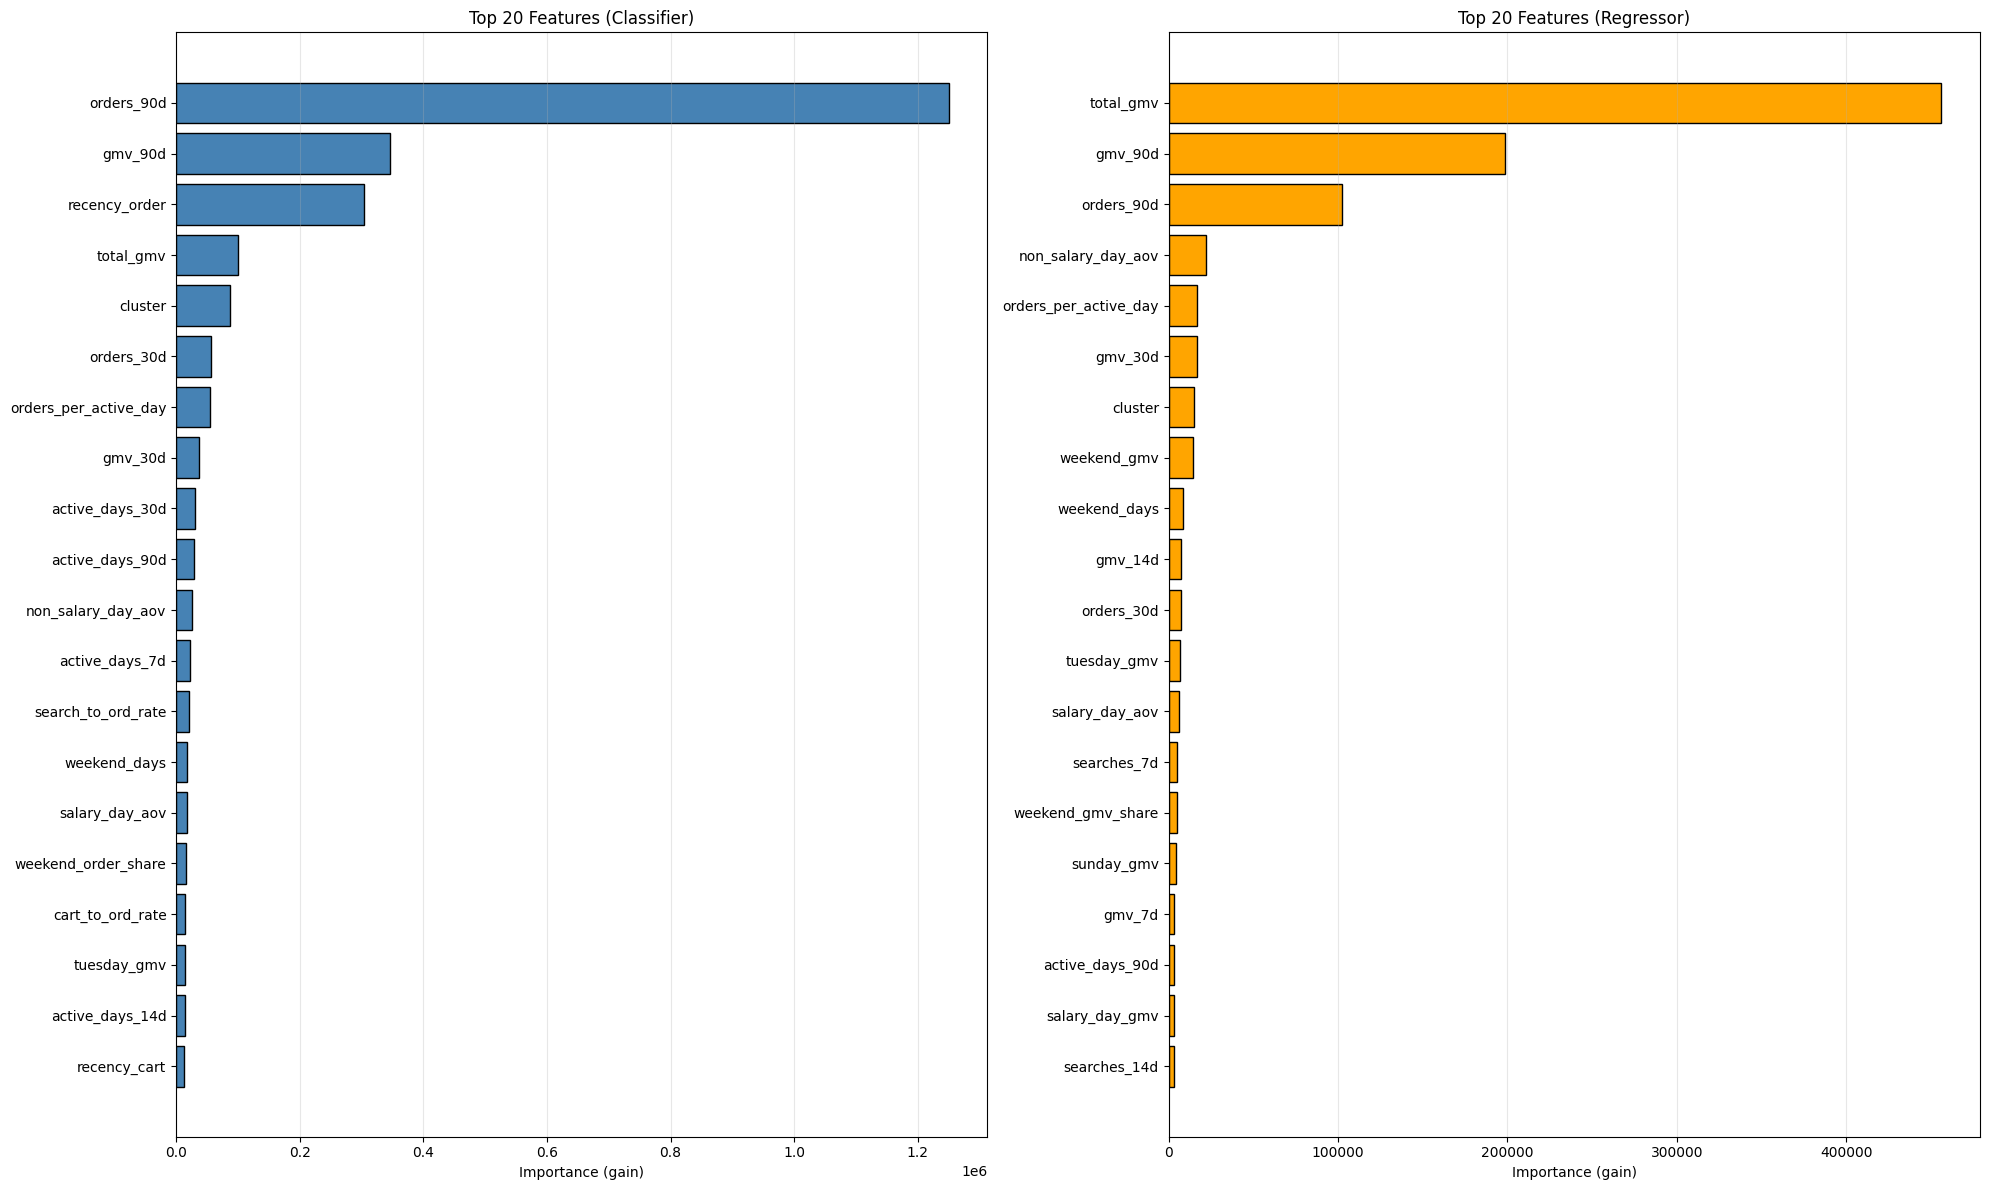


Feature importance plot saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\graphs\03_lgbm_clf_reg_v2\feature_importance_lgbm_clf_reg_optimized.png


In [26]:
# FEATURE IMPORTANCE (OPTIMIZED MODELS)
print("FEATURE IMPORTANCE (OPTIMIZED MODELS)")

# Classifier importance
feature_importance_clf_opt = pd.DataFrame({
    "feature": feature_cols,
    "importance": clf_optimized.feature_importance(importance_type = "gain"),
}).sort_values("importance", ascending = False)

print("\nTop 20 features (optimized classifier):")
print(feature_importance_clf_opt.head(20))

# Regressor importance
feature_importance_reg_opt = pd.DataFrame({
    "feature": feature_cols,
    "importance": reg_optimized.feature_importance(importance_type = "gain"),
}).sort_values("importance", ascending = False)

print("\nTop 20 features (optimized regressor):")
print(feature_importance_reg_opt.head(20))

# VISUALIZE FEATURE IMPORTANCE
fig, axes = plt.subplots(1, 2, figsize = (20, 12))

# Classifier importance plot
top_n = 20
axes[0].barh(
    feature_importance_clf_opt.head(top_n)["feature"],
    feature_importance_clf_opt.head(top_n)["importance"],
    color = "steelblue",
    edgecolor = "black"
)
axes[0].set_xlabel("Importance (gain)")
axes[0].set_title(f"Top {top_n} Features (Classifier)")
axes[0].grid(alpha = 0.3, axis = "x")
axes[0].invert_yaxis()

# Regressor importance plot
axes[1].barh(
    feature_importance_reg_opt.head(top_n)["feature"],
    feature_importance_reg_opt.head(top_n)["importance"],
    color = "orange",
    edgecolor = "black"
)
axes[1].set_xlabel("Importance (gain)")
axes[1].set_title(f"Top {top_n} Features (Regressor)")
axes[1].grid(alpha = 0.3, axis = "x")
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(REPORTS_MODELS_GRAPHS_DIR / '03_lgbm_clf_reg_v2' / "feature_importance_lgbm_clf_reg_optimized.png", dpi = 150)
plt.show()

print(f"\nFeature importance plot saved to: {REPORTS_MODELS_GRAPHS_DIR / '03_lgbm_clf_reg_v2' / 'feature_importance_lgbm_clf_reg_optimized.png'}")

CONFUSION MATRIX (CLASSIFIER)

Confusion Matrix:
[[17336  5631]
 [ 5579 21454]]

True Negatives: 17336
False Positives: 5631
False Negatives: 5579
True Positives: 21454


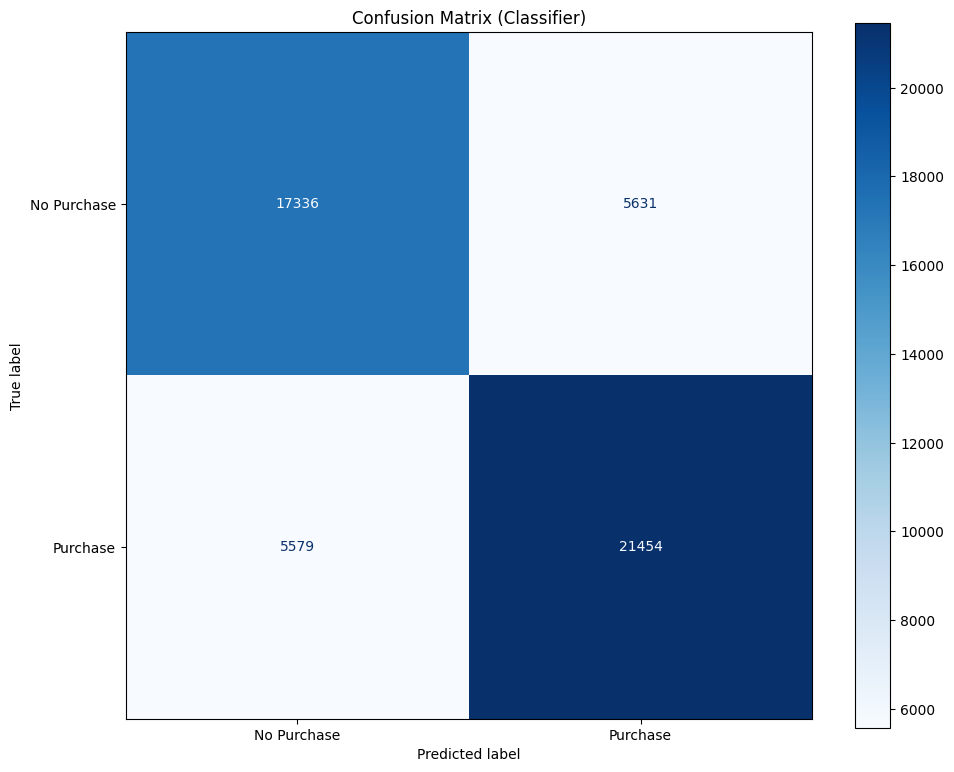

Confusion matrix saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\graphs\03_lgbm_clf_reg_v2\confusion_matrix_lgbm_clf.png


In [25]:
# CONFUSION MATRIX (CLASSIFIER)
print("CONFUSION MATRIX (CLASSIFIER)")

# Predicting on validation
y_clf_val_pred_opt_binary = (y_clf_val_pred_opt > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_clf_val, y_clf_val_pred_opt_binary)

print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives: {cm[1, 1]}")

# Visualization
fig, ax = plt.subplots(figsize = (10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Purchase", "Purchase"])
disp.plot(cmap = "Blues", ax = ax)
ax.set_title("Confusion Matrix (Classifier)")
plt.tight_layout()
fig.savefig(REPORTS_MODELS_GRAPHS_DIR / '03_lgbm_clf_reg_v2' / "confusion_matrix_lgbm_clf.png", dpi = 150)
plt.show()

print(f"Confusion matrix saved to: {REPORTS_MODELS_GRAPHS_DIR / '03_lgbm_clf_reg_v2' / 'confusion_matrix_lgbm_clf.png'}")

PREDICTION DISTRIBUTION (REGRESSOR)


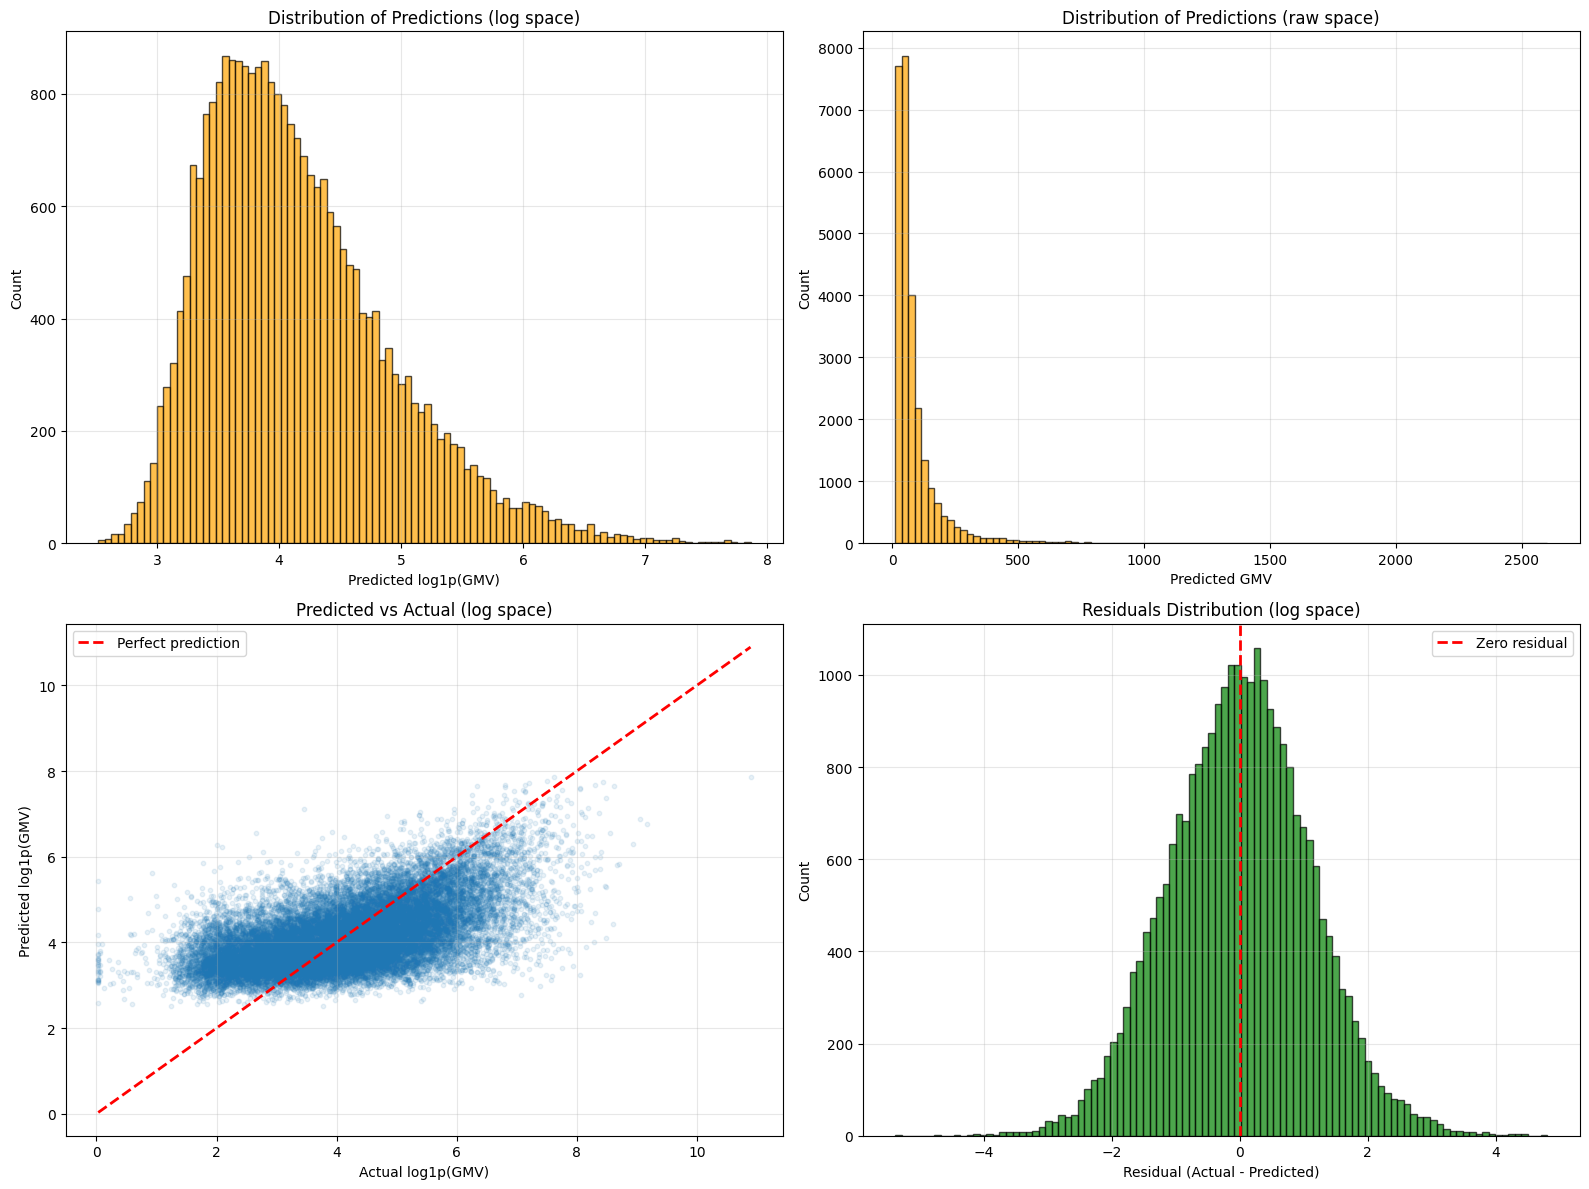

Regressor predictions saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\graphs\03_lgbm_clf_reg_v2\lgbm_reg_predictions.png

Residuals statistics (log space):
  Mean: -0.0027
  Std: 1.1060
  Min: -5.3931
  Max: 4.8076


In [27]:
# PREDICTION DISTRIBUTION (REGRESSOR)
print("PREDICTION DISTRIBUTION (REGRESSOR)")

# Validation predictions (in logarithmic space)
y_reg_val_pred_opt_log = reg_optimized.predict(X_reg_val)
y_reg_val_pred_opt_raw = np.expm1(y_reg_val_pred_opt_log)
y_reg_val_raw = np.expm1(y_reg_val)

fig, axes = plt.subplots(2, 2, figsize = (16, 12))

# Graph 1: Prediction distribution (log space)
axes[0, 0].hist(y_reg_val_pred_opt_log, bins = 100, alpha = 0.7, edgecolor = "black", color = "orange")
axes[0, 0].set_title("Distribution of Predictions (log space)")
axes[0, 0].set_xlabel("Predicted log1p(GMV)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha = 0.3)

# Graph 2: Prediction distribution (raw space)
axes[0, 1].hist(y_reg_val_pred_opt_raw, bins = 100, alpha = 0.7, edgecolor = "black", color = "orange")
axes[0, 1].set_title("Distribution of Predictions (raw space)")
axes[0, 1].set_xlabel("Predicted GMV")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha = 0.3)

# Graph 3: Prediction vs Reality (log space)
axes[1, 0].scatter(y_reg_val, y_reg_val_pred_opt_log, alpha = 0.1, s = 10)
axes[1, 0].plot([y_reg_val.min(), y_reg_val.max()], [y_reg_val.min(), y_reg_val.max()], "r--", linewidth = 2, label = "Perfect prediction")
axes[1, 0].set_title("Predicted vs Actual (log space)")
axes[1, 0].set_xlabel("Actual log1p(GMV)")
axes[1, 0].set_ylabel("Predicted log1p(GMV)")
axes[1, 0].legend()
axes[1, 0].grid(alpha = 0.3)

# Graph 4: Remaining space (log space)
residuals_log = y_reg_val - y_reg_val_pred_opt_log
axes[1, 1].hist(residuals_log, bins = 100, alpha = 0.7, edgecolor = "black", color = "green")
axes[1, 1].set_title("Residuals Distribution (log space)")
axes[1, 1].set_xlabel("Residual (Actual - Predicted)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].axvline(0, color = "red", linestyle = "--", linewidth = 2, label = "Zero residual")
axes[1, 1].legend()
axes[1, 1].grid(alpha = 0.3)

plt.tight_layout()
fig.savefig(REPORTS_MODELS_GRAPHS_DIR / '03_lgbm_clf_reg_v2' / "lgbm_reg_predictions.png", dpi = 150)
plt.show()

print(f"Regressor predictions saved to: {REPORTS_MODELS_GRAPHS_DIR / '03_lgbm_clf_reg_v2' / 'lgbm_reg_predictions.png'}")

# Статистика остатков
print("\nResiduals statistics (log space):")
print(f"  Mean: {residuals_log.mean():.4f}")
print(f"  Std: {residuals_log.std():.4f}")
print(f"  Min: {residuals_log.min():.4f}")
print(f"  Max: {residuals_log.max():.4f}")

In [28]:
# ERROR ANALYSIS
print("ERROR ANALYSIS")

# Obtain predictions for all users
P_buy_all = clf_optimized.predict(X)
predicted_gmv_log_all = reg_optimized.predict(X)
predicted_gmv_all = np.expm1(predicted_gmv_log_all)
final_prediction_all = P_buy_all * predicted_gmv_all
final_prediction_all = np.clip(final_prediction_all, 0, None)

# Counting error for each user
errors = np.abs(y - final_prediction_all)
errors_log = np.abs(np.log1p(y) - np.log1p(final_prediction_all))

worst_indices = np.argsort(errors_log)[-10:][::-1]

print("\nTop 10 worst predictions:")
for idx in worst_indices:
    user_id = user_ids[idx]
    actual = y[idx]
    predicted = final_prediction_all[idx]
    error_log = errors_log[idx]
    
    print(f"User {user_id}:")
    print(f"  Actual GMV: {actual:.2f}")
    print(f"  Predicted GMV: {predicted:.2f}")
    print(f"  Error (log): {error_log:.4f}")
    print(f"  Error (raw): {errors[idx]:.2f}")
    print()

# Creating a table for analysis
analysis_df = pd.DataFrame({
    "user_id": user_ids,
    "actual": y,
    "predicted": final_prediction_all,
    "error_abs": errors,
    "error_log": errors_log,
})

# Error statistics
print("Error statistics:")
print(f"  Mean absolute error: {errors.mean():.2f}")
print(f"  Median absolute error: {np.median(errors):.2f}")
print(f"  Mean log error: {errors_log.mean():.4f}")
print(f"  Median log error: {np.median(errors_log):.4f}")

# Saving the table
analysis_path = REPORTS_MODELS_LOGS_DIR / '03_lgbm_clf_reg_v2' / f"lgbm_clf_reg_error_analysis_{timestamp}.csv"
analysis_df.to_csv(analysis_path, index = False)
print(f"\nError analysis saved to: {analysis_path}")

ERROR ANALYSIS

Top 10 worst predictions:
User 9355:
  Actual GMV: 0.00
  Predicted GMV: 1247.71
  Error (log): 7.1299
  Error (raw): 1247.71

User 182646:
  Actual GMV: 0.00
  Predicted GMV: 1102.19
  Error (log): 7.0060
  Error (raw): 1102.19

User 355760:
  Actual GMV: 5408.92
  Predicted GMV: 4.12
  Error (log): 6.9621
  Error (raw): 5404.80

User 878115:
  Actual GMV: 0.00
  Predicted GMV: 1049.57
  Error (log): 6.9571
  Error (raw): 1049.57

User 493918:
  Actual GMV: 3135.53
  Predicted GMV: 2.03
  Error (log): 6.9408
  Error (raw): 3133.49

User 516209:
  Actual GMV: 0.00
  Predicted GMV: 1028.92
  Error (log): 6.9372
  Error (raw): 1028.92

User 878419:
  Actual GMV: 0.00
  Predicted GMV: 689.19
  Error (log): 6.5370
  Error (raw): 689.19

User 438377:
  Actual GMV: 0.00
  Predicted GMV: 673.51
  Error (log): 6.5140
  Error (raw): 673.51

User 401208:
  Actual GMV: 0.00
  Predicted GMV: 640.15
  Error (log): 6.4633
  Error (raw): 640.15

User 531419:
  Actual GMV: 0.00
  Predi

### **THRESHOLD OPTIMIZATION**

In [ ]:
# THRESHOLD OPTIMIZATION WITH OPTIMIZED MODELS
# Find the optimal alpha that minimizes overall RMSLE on val set
# Re-compute predictions on validation set using OPTIMIZED models
P_buy_val = clf_optimized.predict(X_clf_val)
predicted_gmv_log_val = reg_optimized.predict(X_clf_val)
predicted_gmv_val = np.expm1(predicted_gmv_log_val)
predicted_gmv_val = np.clip(predicted_gmv_val, 0, None)

y_val = y[val_idx]

print(f"Val size: {len(y_val)}")
print(f"Val positive: {(y_val > 0).sum()}")
print(f"P_buy_val range: [{P_buy_val.min():.4f}, {P_buy_val.max():.4f}]")
print(f"predicted_gmv_val range: [{predicted_gmv_val.min():.2f}, {predicted_gmv_val.max():.2f}]")

Val size: 50000
Val positive: 27033
P_buy_val range: [0.0353, 0.9952]
predicted_gmv_val range: [9.79, 2601.70]


In [ ]:
# POWER GATE ((P_buy ^ alpha) * predicted_gmv)
# Continuous control: alpha > 1 compresses low probabilities more
alphas = np.arange(0.5, 5.0, 0.01)
power_results = []

for alpha in alphas:
    pred = (P_buy_val ** alpha) * predicted_gmv_val
    pred = np.clip(pred, 0, None)
    score = rmsle(y_val, pred)
    power_results.append({
        "alpha": alpha,
        "rmsle": score,
        "mean_pred": pred.mean(),
    })

power_df = pd.DataFrame(power_results)
best_power = power_df.loc[power_df["rmsle"].idxmin()]

print(f"Best alpha: {best_power['alpha']:.2f}")
print(f"Best RMSLE: {best_power['rmsle']:.4f}")
print(f"Mean prediction at best alpha: {best_power['mean_pred']:.4f}")

# Save optimal alpha
OPTIMAL_ALPHA = best_power["alpha"]
print(f"\nOptimal alpha saved: OPTIMAL_ALPHA = {OPTIMAL_ALPHA:.2f}")

Best alpha: 2.65
Best RMSLE: 1.6806
Mean prediction at best alpha: 38.9495

Optimal alpha saved: OPTIMAL_ALPHA = 2.65


In [ ]:
# FINAL EVALUATION WITH OPTIMAL ALPHA
# Final prediction with power gate using optimal alpha
final_prediction_val = (P_buy_val ** OPTIMAL_ALPHA) * predicted_gmv_val
final_prediction_val = np.clip(final_prediction_val, 0, None)

print(f"Val prediction statistics:")
print(f"  Mean: {final_prediction_val.mean():.4f}")
print(f"  Median: {np.median(final_prediction_val):.4f}")
print(f"  Max: {final_prediction_val.max():.4f}")
print(f"  Min: {final_prediction_val.min():.4f}")
print(f"  Zeros: {(final_prediction_val == 0).sum()}")
print(f"  Positive: {(final_prediction_val > 0).sum()}")

# CORRECT evaluation: only on val users
val_rmsle_final = rmsle(y_val, final_prediction_val)

print(f"\nFinal Val RMSLE: {val_rmsle_final:.4f}")
print(f"Soft baseline RMSLE: {soft_rmsle:.4f}")
print(f"Improvement: {(soft_rmsle - val_rmsle_final) / soft_rmsle * 100:.2f}%")

Val prediction statistics:
  Mean: 38.9495
  Median: 7.4300
  Max: 2558.9845
  Min: 0.0031
  Zeros: 0
  Positive: 50000

Final Val RMSLE: 1.6806
Soft baseline RMSLE: 1.9124
Improvement: 12.12%


In [33]:
# BASELINE COMPARISON

# Baseline 1: predicting mean
baseline_1 = np.full_like(y_val, y_val.mean())
baseline_1_rmsle = rmsle(y_val, baseline_1)
print(f"Baseline 1 (mean on val): {baseline_1_rmsle:.4f}")

# Baseline 2: predicting median
baseline_2 = np.full_like(y_val, np.median(y_val))
baseline_2_rmsle = rmsle(y_val, baseline_2)
print(f"Baseline 2 (median on val): {baseline_2_rmsle:.4f}")

# Baseline 3: predicting 0 for everyone
baseline_3 = np.zeros_like(y_val)
baseline_3_rmsle = rmsle(y_val, baseline_3)
print(f"Baseline 3 (zero): {baseline_3_rmsle:.4f}")

# Our model
print(f"Our model: {val_rmsle_final:.4f}")

print(f"\nClassifier Val AUC (optimized): {val_auc_opt:.4f}")
print(f"Regressor Val RMSE log (optimized): {val_rmse_log_opt:.4f}")
print(f"Optimal alpha: {OPTIMAL_ALPHA:.2f}")
print(f"Final Val RMSLE: {val_rmsle_final:.4f}")
print(f"Baseline (mean) RMSLE: {baseline_1_rmsle:.4f}")
print(f"Improvement over baseline: {(baseline_1_rmsle - val_rmsle_final) / baseline_1_rmsle * 100:.2f}%")

Baseline 1 (mean on val): 3.1815
Baseline 2 (median on val): 2.2911
Baseline 3 (zero): 3.2053
Our model: 1.6806

Classifier Val AUC (optimized): 0.8570
Regressor Val RMSE log (optimized): 1.1060
Optimal alpha: 2.65
Final Val RMSLE: 1.6806
Baseline (mean) RMSLE: 3.1815
Improvement over baseline: 47.18%


In [34]:
# FEATURE IMPORTANCE FOR OPTIMIZED MODELS

# Classifier
feature_importance_clf_opt = pd.DataFrame({
    "feature": feature_cols,
    "importance": clf_optimized.feature_importance(importance_type = "gain"),
}).sort_values("importance", ascending = False)

print("Top 15 features (optimized classifier):")
print(feature_importance_clf_opt.head(15))

# Regressor
feature_importance_reg_opt = pd.DataFrame({
    "feature": feature_cols,
    "importance": reg_optimized.feature_importance(importance_type = "gain"),
}).sort_values("importance", ascending = False)

print("\nTop 15 features (optimized regressor):")
print(feature_importance_reg_opt.head(15))

Top 15 features (optimized classifier):
                  feature    importance
18             orders_90d  1.250458e+06
28                gmv_90d  3.458500e+05
1           recency_order  3.033421e+05
45              total_gmv  1.001321e+05
60                cluster  8.768533e+04
14             orders_30d  5.559504e+04
42  orders_per_active_day  5.419462e+04
26                gmv_30d  3.731521e+04
13        active_days_30d  3.111486e+04
17        active_days_90d  2.871929e+04
49     non_salary_day_aov  2.609224e+04
5          active_days_7d  2.177437e+04
38     search_to_ord_rate  2.057885e+04
30           weekend_days  1.717491e+04
48         salary_day_aov  1.668201e+04

Top 15 features (optimized regressor):
                  feature     importance
45              total_gmv  456203.659291
28                gmv_90d  198724.869941
18             orders_90d  102278.755518
49     non_salary_day_aov   22050.029463
42  orders_per_active_day   16947.409411
26                gmv_30d   16794.